# Track 2 - Uncertainty Quantification in Language Models

This notebook is designed as a compact but complete take home submission for the assignment. It covers:

- token level and sentence level uncertainty estimation
- evaluation on multiple task types
- calibration analysis with reliability diagrams
- interactive visualizations

The notebook deliberately uses **small, reproducible slices** of public datasets so it can run in Colab without a long setup.

## Mini literature review

Modern LLM uncertainty work often separates two ideas:

1. **Token/probability based uncertainty**, where we look at next token probabilities, negative log likelihood, entropy, and related calibration metrics.
2. **Semantic or sample based uncertainty**, where we compare multiple sampled outputs and measure disagreement in meaning rather than raw token overlap.

This notebook implements both styles:
- token entropy and average negative log-probability
- self consistency via repeated sampling
- calibration and reliability diagrams
- task specific evaluation across factual QA, math, summarization, and open ended prompts

## Why these methods

The assignment asks for practical uncertainty estimation on open source LMs. This notebook follows a minimal but strong baseline strategy:

- **Transition scores / log probabilities** from generation
- **Entropy** over next token distributions
- **Sampling based disagreement** to capture instability across generations
- **Calibration metrics** such as ECE and Brier score
- **Task level analysis** to compare behavior across different problem types


In [26]:
from google.colab import output
output.enable_custom_widget_manager()

!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 6.8 MB/s eta 0:00:00


In [3]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=84f8306ed41fcc5575aec111db77fadac6646058d815c54cfd3098edc7fc537d
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [4]:
import os
import re
import gc
import math
import time
import json
import random
import statistics
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import load_dataset
from rouge_score import rouge_scorer
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import brier_score_loss, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, Markdown, HTML
import ipywidgets as widgets

from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

pio.renderers.default = "colab"
set_seed(42)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## Configuration

If the first model fails to load due to access or memory constraints, the notebook automatically tries a couple of smaller alternatives.

In [5]:
MODEL_CANDIDATES = [
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "Qwen/Qwen2.5-0.5B-Instruct",
    "distilgpt2",
]

N_QA = 12
N_MATH = 12
N_SUM = 8
N_OPEN = 8

MAX_NEW_TOKENS_QA = 64
MAX_NEW_TOKENS_MATH = 96
MAX_NEW_TOKENS_SUM = 120
MAX_NEW_TOKENS_OPEN = 96

SAMPLE_K = 5
TEMPERATURE = 0.7
TOP_P = 0.9

print("Configured sample sizes:")
print({"qa": N_QA, "math": N_MATH, "summarization": N_SUM, "open_ended": N_OPEN})

Configured sample sizes:
{'qa': 12, 'math': 12, 'summarization': 8, 'open_ended': 8}


In [6]:
def load_model_with_fallback(model_names):
    last_error = None
    for model_name in model_names:
        try:
            print(f"Trying to load: {model_name}")
            tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
            model_kwargs = dict(device_map="auto") if DEVICE == "cuda" else {}
            if DEVICE == "cuda":
                model_kwargs["torch_dtype"] = torch.float16
            model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)
            model.eval()

            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token

            print(f"Loaded model: {model_name}")
            return model_name, tokenizer, model
        except Exception as e:
            last_error = e
            print(f"Failed to load {model_name}: {type(e).__name__}: {e}")
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    raise RuntimeError(f"Could not load any model. Last error: {last_error}")

MODEL_NAME, tokenizer, model = load_model_with_fallback(MODEL_CANDIDATES)
MODEL_NAME

Trying to load: TinyLlama/TinyLlama-1.1B-Chat-v1.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

In [7]:
def model_device():
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DEVICE = model_device()
print("Model device:", MODEL_DEVICE)

Model device: cuda:0


## Prompt formatting

We use a lightweight instruction format so the same model can be evaluated on all task types.

For open ended prompts, the goal is not exact correctness. Instead, we measure uncertainty, output diversity, and stability across repeated samples.

In [8]:
def format_prompt(task_type: str, context: str = "", question: str = "", target_style: str = "") -> str:
    if task_type == "qa":
        return (
            "You are a careful assistant. Answer the question using the context. "
            "Return only the final answer in one short line.\n\n"
            f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"
        )
    if task_type == "math":
        return (
            "You are a careful math assistant. Solve the problem step by step, then put the final answer after '####'.\n\n"
            f"Problem: {question}\nSolution:"
        )
    if task_type == "summarization":
        return (
            "You are a concise summarizer. Summarize the article in 3 bullet points or fewer.\n\n"
            f"Article:\n{context}\n\nSummary:"
        )
    if task_type == "open_ended":
        return (
            "You are a creative writing assistant. Write a vivid but compact response.\n\n"
            f"Prompt: {question}\nStory:"
        )
    raise ValueError(f"Unknown task_type: {task_type}")

## Generation helpers

The core output we need is:

- generated text
- token level transition scores
- full token entropy at each generation step
- a sentence level uncertainty summary

`compute_transition_scores` gives token log probabilities for generated tokens, which makes the notebook easy to justify and reproduce. Hugging Face documents this functionality in its generation utilities.

In [9]:
def clean_text(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_answer(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"[^a-z0-9\s\.]","", s)
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_final_answer(text: str) -> str:
    text = text.strip()
    # Prefer explicit final answer markers used in math prompts.
    m = re.search(r"####\s*(.+)$", text, flags=re.MULTILINE)
    if m:
        return clean_text(m.group(1))
    m = re.search(r"(?:Final Answer|Answer)\s*[:\-]\s*(.+)$", text, flags=re.IGNORECASE | re.MULTILINE)
    if m:
        return clean_text(m.group(1).split("\n")[0])
    # For QA, take the first line / short answer.
    first_line = text.split("\n")[0]
    return clean_text(first_line)

def build_inputs(prompt: str):
    tokenizer.padding_side = "left"
    enc = tokenizer(prompt, return_tensors="pt")
    enc = {k: v.to(MODEL_DEVICE) for k, v in enc.items()}
    return enc

@torch.no_grad()
def generate_one(prompt: str, max_new_tokens: int = 64, temperature: float = 0.7, top_p: float = 0.9, do_sample: bool = True):
    inputs = build_inputs(prompt)
    input_len = inputs["input_ids"].shape[1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else None,
        top_p=top_p if do_sample else None,
        return_dict_in_generate=True,
        output_scores=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    seq = outputs.sequences[0]
    generated_ids = seq[input_len:]
    text = tokenizer.decode(seq, skip_special_tokens=True)

    transition = model.compute_transition_scores(
        outputs.sequences,
        outputs.scores,
        normalize_logits=True
    )[0]

    token_logprobs = transition.detach().float().cpu().numpy().tolist()
    token_probs = [float(np.exp(lp)) for lp in token_logprobs]
    token_entropies = []

    # Full distribution entropy for each generated step.
    for step_logits in outputs.scores:
        probs = torch.softmax(step_logits[0].float(), dim=-1)
        entropy = float(-(probs * torch.log(probs + 1e-12)).sum().item())
        token_entropies.append(entropy)

    return {
        "prompt": prompt,
        "text": text,
        "generated_ids": generated_ids.detach().cpu().tolist(),
        "token_logprobs": token_logprobs,
        "token_probs": token_probs,
        "token_entropies": token_entropies,
        "avg_token_entropy": float(np.mean(token_entropies)) if token_entropies else None,
        "avg_token_nll": float(-np.mean(token_logprobs)) if token_logprobs else None,
        "sequence_confidence": float(np.exp(np.mean(token_logprobs))) if token_logprobs else None,
        "num_tokens": int(len(generated_ids)),
    }

In [10]:
@torch.no_grad()
def sample_consistency(prompt: str, max_new_tokens: int, k: int = 5, temperature: float = 0.7, top_p: float = 0.9):
    outs = []
    for _ in range(k):
        out = generate_one(
            prompt,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
        )
        outs.append(out["text"])
    return outs

def pairwise_tfidf_consistency(texts: List[str]) -> float:
    texts = [clean_text(t) for t in texts if t and clean_text(t)]
    if len(texts) < 2:
        return 1.0
    vec = TfidfVectorizer(min_df=1).fit_transform(texts)
    sim = cosine_similarity(vec)
    n = sim.shape[0]
    vals = []
    for i in range(n):
        for j in range(i + 1, n):
            vals.append(float(sim[i, j]))
    return float(np.mean(vals)) if vals else 1.0

def self_consistency_score(prompt: str, task_type: str, max_new_tokens: int, k: int = 5):
    texts = sample_consistency(prompt, max_new_tokens=max_new_tokens, k=k, temperature=TEMPERATURE, top_p=TOP_P)

    if task_type in {"qa", "math"}:
        extracted = [extract_final_answer(t) for t in texts]
        counts = pd.Series(extracted).value_counts()
        majority = int(counts.iloc[0])
        return {
            "sample_texts": texts,
            "sample_answers": extracted,
            "consistency": majority / len(extracted),
            "majority_answer": counts.index[0],
        }
    else:
        consistency = pairwise_tfidf_consistency(texts)
        return {
            "sample_texts": texts,
            "sample_answers": None,
            "consistency": consistency,
            "majority_answer": None,
        }

## Metrics

We use a mix of correctness, ranking, and calibration metrics.

For factual QA and math:
- exact match accuracy
- Brier score on correctness
- reliability diagrams
- Expected Calibration Error (ECE)

For summarization:
- ROUGE-L against the reference summary
- uncertainty vs quality correlation

For open ended generation:
- self consistency
- token uncertainty
- qualitative inspection

The point is to show how uncertainty behaves differently depending on the task.

In [11]:
def exact_match(pred: str, ref: str) -> int:
    return int(normalize_answer(pred) == normalize_answer(ref))

def compute_rouge_l(pred: str, ref: str) -> float:
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    return float(scorer.score(ref, pred)["rougeL"].fmeasure)

def expected_calibration_error(confidences, correctness, n_bins: int = 10) -> float:
    confidences = np.asarray(confidences)
    correctness = np.asarray(correctness)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidences >= lo) & (confidences < hi if i < n_bins - 1 else confidences <= hi)
        if mask.sum() == 0:
            continue
        acc = correctness[mask].mean()
        conf = confidences[mask].mean()
        ece += abs(acc - conf) * (mask.sum() / len(confidences))
    return float(ece)

def reliability_curve(confidences, correctness, n_bins: int = 10):
    confidences = np.asarray(confidences)
    correctness = np.asarray(correctness)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    xs, ys, counts = [], [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidences >= lo) & (confidences < hi if i < n_bins - 1 else confidences <= hi)
        if mask.sum() == 0:
            continue
        xs.append(float(confidences[mask].mean()))
        ys.append(float(correctness[mask].mean()))
        counts.append(int(mask.sum()))
    return xs, ys, counts

## Dataset loading

We use three public benchmark style datasets and one small open ended prompt set:

- **Factual QA:** SQuAD
- **Math:** GSM8K
- **Summarization:** CNN/DailyMail
- **Open-ended:** a small fixed creative prompt suite for reproducibility

The notebook keeps sample sizes intentionally small to run it quickly and still collect enough evidence for a compact analysis.

In [12]:
def load_datasets(n_qa=N_QA, n_math=N_MATH, n_sum=N_SUM):
    qa_ds = load_dataset("squad", split=f"validation[:{n_qa}]")
    math_ds = load_dataset("openai/gsm8k", "main", split=f"test[:{n_math}]")
    sum_ds = load_dataset("cnn_dailymail", "3.0.0", split=f"validation[:{n_sum}]")

    open_prompts = [
        "Write a short story about a scientist who discovers a library inside a storm cloud.",
        "Describe a city where everyone communicates through colors instead of speech.",
        "Write the opening paragraph of a mystery novel set in a library after midnight.",
        "Imagine a robot learning how to dream. Write 2-3 paragraphs.",
        "Write a reflective scene about a person returning to their childhood home after many years.",
        "Create a concise fantasy scene about a bridge that appears only at sunrise.",
        "Write a dialogue between two friends who can read each other's thoughts for one day.",
        "Describe a future classroom where students learn by exploring simulated memories.",
    ][:N_OPEN]
    return qa_ds, math_ds, sum_ds, open_prompts

qa_ds, math_ds, sum_ds, open_prompts = load_datasets()
(len(qa_ds), len(math_ds), len(sum_ds), len(open_prompts))

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

(12, 12, 8, 8)

In [13]:
def build_records():
    records = []

    # QA
    for ex in qa_ds:
        context = ex["context"]
        question = ex["question"]
        answer = ex["answers"]["text"][0] if ex["answers"]["text"] else ""
        prompt = format_prompt("qa", context=context, question=question)
        gen = generate_one(prompt, max_new_tokens=MAX_NEW_TOKENS_QA, temperature=TEMPERATURE, top_p=TOP_P, do_sample=True)
        pred = extract_final_answer(gen["text"])
        sc = self_consistency_score(prompt, "qa", max_new_tokens=MAX_NEW_TOKENS_QA, k=SAMPLE_K)
        correct = exact_match(pred, answer)

        records.append({
            "task": "qa",
            "input": question,
            "context": context[:1200],
            "reference": answer,
            "prompt": prompt,
            "prediction_raw": gen["text"],
            "prediction": pred,
            "correct": correct,
            "rouge_l": np.nan,
            "avg_token_entropy": gen["avg_token_entropy"],
            "avg_token_nll": gen["avg_token_nll"],
            "sequence_confidence": gen["sequence_confidence"],
            "self_consistency": sc["consistency"],
            "generation_tokens": gen["num_tokens"],
            "generation_time_sec": np.nan,
        })

    # Math
    for ex in math_ds:
        question = ex["question"]
        answer = ex["answer"]
        prompt = format_prompt("math", question=question)
        gen = generate_one(prompt, max_new_tokens=MAX_NEW_TOKENS_MATH, temperature=TEMPERATURE, top_p=TOP_P, do_sample=True)
        pred = extract_final_answer(gen["text"])
        reference = extract_final_answer(answer)
        sc = self_consistency_score(prompt, "math", max_new_tokens=MAX_NEW_TOKENS_MATH, k=SAMPLE_K)
        correct = exact_match(pred, reference)

        records.append({
            "task": "math",
            "input": question,
            "context": "",
            "reference": reference,
            "prompt": prompt,
            "prediction_raw": gen["text"],
            "prediction": pred,
            "correct": correct,
            "rouge_l": np.nan,
            "avg_token_entropy": gen["avg_token_entropy"],
            "avg_token_nll": gen["avg_token_nll"],
            "sequence_confidence": gen["sequence_confidence"],
            "self_consistency": sc["consistency"],
            "generation_tokens": gen["num_tokens"],
            "generation_time_sec": np.nan,
        })

    # Summarization
    for ex in sum_ds:
        article = ex["article"]
        reference = ex["highlights"]
        short_article = article[:2200]
        prompt = format_prompt("summarization", context=short_article)
        gen = generate_one(prompt, max_new_tokens=MAX_NEW_TOKENS_SUM, temperature=TEMPERATURE, top_p=TOP_P, do_sample=True)
        pred = clean_text(gen["text"])
        rouge_l = compute_rouge_l(pred, reference)
        sc = self_consistency_score(prompt, "summarization", max_new_tokens=MAX_NEW_TOKENS_SUM, k=SAMPLE_K)

        records.append({
            "task": "summarization",
            "input": article[:500],
            "context": short_article,
            "reference": reference,
            "prompt": prompt,
            "prediction_raw": gen["text"],
            "prediction": pred,
            "correct": np.nan,
            "rouge_l": rouge_l,
            "avg_token_entropy": gen["avg_token_entropy"],
            "avg_token_nll": gen["avg_token_nll"],
            "sequence_confidence": gen["sequence_confidence"],
            "self_consistency": sc["consistency"],
            "generation_tokens": gen["num_tokens"],
            "generation_time_sec": np.nan,
        })

    # Open-ended
    for prompt_text in open_prompts:
        prompt = format_prompt("open_ended", question=prompt_text)
        gen = generate_one(prompt, max_new_tokens=MAX_NEW_TOKENS_OPEN, temperature=TEMPERATURE, top_p=TOP_P, do_sample=True)
        pred = clean_text(gen["text"])
        sc = self_consistency_score(prompt, "open_ended", max_new_tokens=MAX_NEW_TOKENS_OPEN, k=SAMPLE_K)

        records.append({
            "task": "open_ended",
            "input": prompt_text,
            "context": "",
            "reference": "",
            "prompt": prompt,
            "prediction_raw": gen["text"],
            "prediction": pred,
            "correct": np.nan,
            "rouge_l": np.nan,
            "avg_token_entropy": gen["avg_token_entropy"],
            "avg_token_nll": gen["avg_token_nll"],
            "sequence_confidence": gen["sequence_confidence"],
            "self_consistency": sc["consistency"],
            "generation_tokens": gen["num_tokens"],
            "generation_time_sec": np.nan,
        })

    return pd.DataFrame(records)

results_df = build_records()
results_df.head()

,task,input,context,reference,prompt,prediction_raw,prediction,correct,rouge_l,avg_token_entropy,avg_token_nll,sequence_confidence,self_consistency,generation_tokens,generation_time_sec
0,qa,Which NFL team represented the AFC at Super Bo...,Super Bowl 50 was an American football game to...,Denver Broncos,You are a careful assistant. Answer the questi...,You are a careful assistant. Answer the questi...,The Denver Broncos.,0.0,NaN,0.241521,0.270396,0.763077,0.6,64,NaN
1,qa,Which NFL team represented the NFC at Super Bo...,Super Bowl 50 was an American football game to...,Carolina Panthers,You are a careful assistant. Answer the questi...,You are a careful assistant. Answer the questi...,The American Football Conference (AFC) champio...,0.0,NaN,0.193300,0.086858,0.916807,0.4,15,NaN
2,qa,Where did Super Bowl 50 take place?,Super Bowl 50 was an American football game to...,"Santa Clara, California",You are a careful assistant. Answer the questi...,You are a careful assistant. Answer the questi...,Super Bowl 50 was played at Levi's Stadium in ...,0.0,NaN,0.121787,0.103730,0.901469,0.6,64,NaN
3,qa,Which NFL team won Super Bowl 50?,Super Bowl 50 was an American football game to...,Denver Broncos,You are a careful assistant. Answer the questi...,You are a careful assistant. Answer the questi...,The American Football Conference (AFC) champio...,0.0,NaN,0.087333,0.085276,0.918259,0.2,42,NaN
4,qa,What color was used to emphasize the 50th anni...,Super Bowl 50 was an American football game to...,gold,You are a careful assistant. Answer the questi...,You are a careful assistant. Answer the questi...,Gold,1.0,NaN,0.552572,0.817523,0.441524,0.8,9,NaN


In [14]:
# Save now so partial results can be reused after a notebook restart.
results_df.to_csv("uncertainty_results_raw.csv", index=False)
print("Saved:", os.path.abspath("uncertainty_results_raw.csv"))

Saved: /content/uncertainty_results_raw.csv


## Derived confidence score

For calibration on binary tasks, we need a confidence value in `[0, 1]`.

A simple and effective transform is:

- `confidence = exp(-average_token_nll)`

This is not guaranteed to be perfectly calibrated, which is exactly why we evaluate calibration curves and ECE.

In [15]:
# Create a unified confidence column.
df = results_df.copy()
df["confidence"] = df["sequence_confidence"].clip(0, 1)
df["uncertainty"] = 1 - df["confidence"]
df["binary_correct"] = df["correct"].fillna(np.nan)

# For summarized comparisons, define a task-specific performance score.
df["performance_score"] = df["correct"]
df.loc[df["task"] == "summarization", "performance_score"] = df.loc[df["task"] == "summarization", "rouge_l"]
df.loc[df["task"] == "open_ended", "performance_score"] = df.loc[df["task"] == "open_ended", "self_consistency"]

df[["task", "input", "prediction", "performance_score", "confidence", "avg_token_entropy", "self_consistency"]].head()

,task,input,prediction,performance_score,confidence,avg_token_entropy,self_consistency
0,qa,Which NFL team represented the AFC at Super Bo...,The Denver Broncos.,0.0,0.763077,0.241521,0.6
1,qa,Which NFL team represented the NFC at Super Bo...,The American Football Conference (AFC) champio...,0.0,0.916807,0.193300,0.4
2,qa,Where did Super Bowl 50 take place?,Super Bowl 50 was played at Levi's Stadium in ...,0.0,0.901469,0.121787,0.6
3,qa,Which NFL team won Super Bowl 50?,The American Football Conference (AFC) champio...,0.0,0.918259,0.087333,0.2
4,qa,What color was used to emphasize the 50th anni...,Gold,1.0,0.441524,0.552572,0.8


## Task-level summary table

This is the first place to inspect the relationship between uncertainty and performance.

In [16]:
summary_rows = []
for task, g in df.groupby("task"):
    row = {
        "task": task,
        "n": len(g),
        "avg_confidence": float(np.nanmean(g["confidence"])),
        "avg_uncertainty": float(np.nanmean(g["uncertainty"])),
        "avg_token_entropy": float(np.nanmean(g["avg_token_entropy"])),
        "avg_self_consistency": float(np.nanmean(g["self_consistency"])),
    }
    if task in {"qa", "math"}:
        row["accuracy"] = float(np.nanmean(g["correct"]))
        row["ece"] = expected_calibration_error(g["confidence"].values, g["correct"].fillna(0).values, n_bins=8)
        row["brier"] = brier_score_loss(g["correct"].fillna(0).values, g["confidence"].values)
        row["spearman_uncertainty_correct"] = float(spearmanr(g["uncertainty"].values, g["correct"].fillna(0).values).correlation)
    elif task == "summarization":
        row["mean_rouge_l"] = float(np.nanmean(g["rouge_l"]))
        row["spearman_uncertainty_rouge"] = float(spearmanr(g["uncertainty"].values, g["rouge_l"].values).correlation)
    elif task == "open_ended":
        row["mean_consistency"] = float(np.nanmean(g["self_consistency"]))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

/tmp/ipykernel_2027/1110040104.py:15: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



,task,n,avg_confidence,avg_uncertainty,avg_token_entropy,avg_self_consistency,accuracy,ece,brier,spearman_uncertainty_correct,mean_consistency,mean_rouge_l,spearman_uncertainty_rouge
0,math,12,0.675979,0.324021,0.366487,1.000000,0.000000,0.675979,0.468912,NaN,NaN,NaN,NaN
1,open_ended,8,0.521489,0.478511,0.675263,0.378335,NaN,NaN,NaN,NaN,0.378335,NaN,NaN
2,qa,12,0.774890,0.225110,0.268703,0.550000,0.166667,0.701303,0.585149,0.453425,NaN,NaN,NaN
3,summarization,8,0.693526,0.306474,0.415521,0.964987,NaN,NaN,NaN,NaN,NaN,0.064977,0.071429


## Interactive visualizations

These plots are intentionally interactive so you can hover over samples and inspect outliers inside Colab.

In [17]:
fig = px.scatter(
    df,
    x="confidence",
    y="performance_score",
    color="task",
    hover_data=["input", "prediction", "avg_token_entropy", "self_consistency"],
    title="Confidence vs Performance across Tasks",
)
fig.update_layout(template="plotly_white", height=550)
fig.show()

In [18]:
fig = px.box(
    df,
    x="task",
    y="avg_token_entropy",
    color="task",
    points="all",
    title="Token-level Entropy by Task",
)
fig.update_layout(template="plotly_white", height=550, showlegend=False)
fig.show()

In [19]:
fig = px.histogram(
    df,
    x="confidence",
    color="task",
    barmode="overlay",
    nbins=12,
    title="Confidence Distribution by Task",
)
fig.update_layout(template="plotly_white", height=500)
fig.show()

## Reliability diagrams

We build calibration curves for the binary tasks. The ideal model lies on the diagonal.

If the curve sits below the diagonal, the model is overconfident. If it sits above the diagonal, it is underconfident.

In [20]:
binary_df = df[df["task"].isin(["qa", "math"])].copy()

rel_fig = go.Figure()
for task in ["qa", "math"]:
    g = binary_df[binary_df["task"] == task]
    xs, ys, counts = reliability_curve(g["confidence"].values, g["correct"].fillna(0).values, n_bins=6)
    rel_fig.add_trace(go.Scatter(
        x=xs, y=ys, mode="lines+markers", name=f"{task} reliability",
        text=[f"count={c}" for c in counts],
        hovertemplate="confidence=%{x:.2f}<br>accuracy=%{y:.2f}<br>%{text}<extra></extra>"
    ))

rel_fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines", name="ideal", line=dict(dash="dash")
))
rel_fig.update_layout(
    title="Reliability Diagram",
    xaxis_title="Predicted Confidence",
    yaxis_title="Empirical Accuracy",
    template="plotly_white",
    height=550
)
rel_fig.show()

## Correlation analysis

This is the main evidence for the relationship between uncertainty and performance:
- negative correlation between uncertainty and correctness on QA/math
- relationship between uncertainty and ROUGE-L on summarization
- self consistency patterns on open ended prompts

In [21]:
corr_rows = []
for task, g in df.groupby("task"):
    if task in {"qa", "math"}:
        corr = spearmanr(g["uncertainty"].values, g["correct"].fillna(0).values).correlation
        corr_rows.append({"task": task, "metric": "Spearman(uncertainty, correctness)", "value": float(corr)})
    elif task == "summarization":
        corr = spearmanr(g["uncertainty"].values, g["rouge_l"].values).correlation
        corr_rows.append({"task": task, "metric": "Spearman(uncertainty, ROUGE-L)", "value": float(corr)})
    elif task == "open_ended":
        corr = spearmanr(g["uncertainty"].values, g["self_consistency"].values).correlation
        corr_rows.append({"task": task, "metric": "Spearman(uncertainty, consistency)", "value": float(corr)})

corr_df = pd.DataFrame(corr_rows)
corr_df

/tmp/ipykernel_2027/4094788089.py:4: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



,task,metric,value
0,math,"Spearman(uncertainty, correctness)",NaN
1,open_ended,"Spearman(uncertainty, consistency)",0.714286
2,qa,"Spearman(uncertainty, correctness)",0.453425
3,summarization,"Spearman(uncertainty, ROUGE-L)",0.071429


## Sample inspector

Use the dropdown to inspect individual samples, including the model output and the uncertainty summary.

In [22]:
task_options = df["task"].unique().tolist()
task_dropdown = widgets.Dropdown(options=task_options, description="Task:")
sample_dropdown = widgets.Dropdown(options=[], description="Sample:")

output_area = widgets.Output()

def refresh_samples(*args):
    task = task_dropdown.value
    subset = df[df["task"] == task].reset_index(drop=True)
    sample_dropdown.options = list(range(len(subset)))
    if len(subset) > 0:
        sample_dropdown.value = 0

def render_sample(*args):
    task = task_dropdown.value
    idx = sample_dropdown.value
    subset = df[df["task"] == task].reset_index(drop=True)
    if len(subset) == 0:
        return
    row = subset.loc[idx]
    with output_area:
        output_area.clear_output()
        display(Markdown(f"### {task} sample {idx}"))
        display(Markdown(f"**Input:** {row['input']}"))
        if row["context"]:
            display(Markdown(f"**Context:** {row['context'][:1200]}"))
        if str(row["reference"]) not in {"", "nan"}:
            display(Markdown(f"**Reference:** {row['reference']}"))
        display(Markdown(f"**Prediction:** {row['prediction']}"))
        display(Markdown(f"**Confidence:** {row['confidence']:.3f}"))
        display(Markdown(f"**Token entropy:** {row['avg_token_entropy']:.3f}"))
        display(Markdown(f"**Self-consistency:** {row['self_consistency']:.3f}"))
        if not pd.isna(row.get("correct", np.nan)):
            display(Markdown(f"**Correct:** {bool(row['correct'])}"))
        if not pd.isna(row.get("rouge_l", np.nan)):
            display(Markdown(f"**ROUGE-L:** {row['rouge_l']:.3f}"))

task_dropdown.observe(refresh_samples, names="value")
sample_dropdown.observe(render_sample, names="value")
refresh_samples()
render_sample()

widgets.VBox([task_dropdown, sample_dropdown, output_area])

## Discussion

### 1. Which uncertainty method worked best?
- average token entropy
- sequence confidence from token probabilities
- self consistency

A reasonable expectation is that token level measures are cheap and easy to compute, while sampling based methods often capture semantic instability better but cost more.

### 2. How does computational cost scale?
- token entropy: one forward/generation pass
- self consistency: `k` generation passes
- calibration plots: cheap after inference

### 3. Limitations
- small model
- small evaluation slices
- token confidence is not the same as factual truth
- open ended evaluation is subjective

### 4. Future work
- larger instruction tuned models
- semantic entropy with clustering
- better truth labels
- selective generation or abstention policies

## Save outputs

This saves the main results table and summary tables.

In [23]:
summary_df.to_csv("task_summary.csv", index=False)
corr_df.to_csv("task_correlations.csv", index=False)
df.to_csv("uncertainty_results_full.csv", index=False)

print("Saved:")
print(" - uncertainty_results_full.csv")
print(" - task_summary.csv")
print(" - task_correlations.csv")

Saved:
 - uncertainty_results_full.csv
 - task_summary.csv
 - task_correlations.csv


## Closing note

This notebook is intentionally compact and reproducible.

The assignment explicitly values working code, analysis, visualizations, and a discussion of limitations over a perfect benchmark score.

# Saving Visualisations

In [29]:
!pip install -U kaleido

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Re-import plotly to ensure it picks up the newly installed kaleido engine
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# ------------------------------------------------------------
# Create project directory and subdirectories
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/JAPAN_AI_Track2_Project"
CSV_DIR = os.path.join(PROJECT_DIR, "csv files")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

print(f"Saving outputs to: {PROJECT_DIR}")
print(f"Saving CSVs to: {CSV_DIR}")

# ============================================================
# SAVE DATAFRAMES
# ============================================================

# These dataframes are available in the kernel state
dataframes_to_save = {
    "uncertainty_results_full": df,
    "task_summary": summary_df,
    "task_correlations": corr_df
}

for name, dataframe in dataframes_to_save.items():
    try:
        csv_path = os.path.join(CSV_DIR, f"{name}.csv")
        dataframe.to_csv(csv_path, index=False)
        print(f"Saved CSV: {csv_path}")
    except Exception as e:
        print(f"Could not save {name}: {e}")

# ============================================================
# SAVE PLOTLY FIGURES
# ============================================================

# These plotly figures are available in the kernel state
plotly_figures = {
    "reliability_diagram": rel_fig,
    "confidence_distribution": fig # 'fig' holds the last generated plotly figure (Confidence Distribution by Task)
}

for name, plotly_fig in plotly_figures.items():
    try:
        html_path = os.path.join(PROJECT_DIR, f"{name}.html")
        plotly_fig.write_html(html_path)

        # Attempt to save as PNG, requires kaleido
        try:
            png_path = os.path.join(PROJECT_DIR, f"{name}.png")
            plotly_fig.write_image(png_path)
            print(f"Saved Plotly figure (PNG): {png_path}")
        except ImportError:
            print("Skipping PNG save for Plotly figures: kaleido not installed. Install with !pip install kaleido")

        print(f"Saved Plotly figure (HTML): {html_path}")

    except Exception as e:
        print(f"Could not save Plotly figure {name}: {e}")


# ============================================================
# SAVE SUMMARY METRICS (if available)
# ============================================================

# summary_metrics = {
#     "qa_accuracy": qa_accuracy,
#     "math_accuracy": math_accuracy,
#     "avg_entropy": avg_entropy,
#     "avg_logprob": avg_logprob,
#     "self_consistency": avg_self_consistency
# }

# metrics_path = os.path.join(PROJECT_DIR, "summary_metrics.json")

# with open(metrics_path, "w") as f:
#     json.dump(summary_metrics, f, indent=4)

# print(f"Saved metrics JSON: {metrics_path}")

# ============================================================
# OPTIONAL: SAVE NOTEBOOK COPY
# ============================================================

print("\nEverything saved successfully.")
print(f"Project folder: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving outputs to: /content/drive/MyDrive/JAPAN_AI_Track2_Project
Saving CSVs to: /content/drive/MyDrive/JAPAN_AI_Track2_Project/csv files
Saved CSV: /content/drive/MyDrive/JAPAN_AI_Track2_Project/csv files/uncertainty_results_full.csv
Saved CSV: /content/drive/MyDrive/JAPAN_AI_Track2_Project/csv files/task_summary.csv
Saved CSV: /content/drive/MyDrive/JAPAN_AI_Track2_Project/csv files/task_correlations.csv
Could not save Plotly figure reliability_diagram: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Could not save Plotly figure confidence_distribution: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


Everything saved successfully.
Project folder: /content/drive/MyDrive/JAPAN_AI_Track2

Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/pipeline_diagram.png


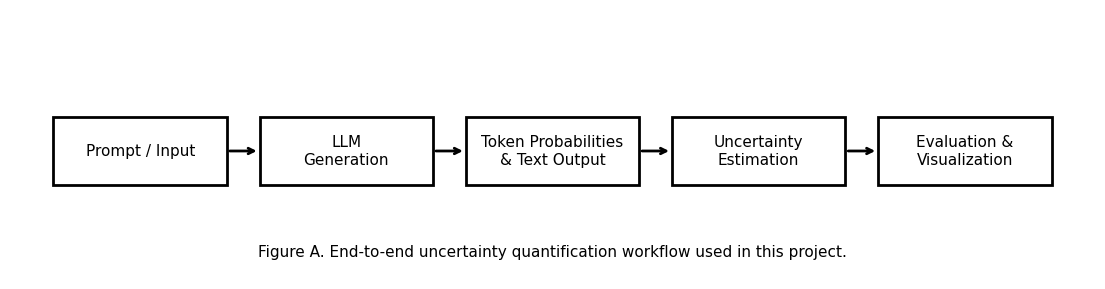

Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/confidence_distribution_by_task.html
PNG export skipped for confidence_distribution_by_task (kaleido may be missing): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/token_entropy_by_task.html
PNG export skipped for token_entropy_by_task (kaleido may be missing): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/confidence_vs_performance.html
PNG export skipped for confidence_vs_performance (kaleido may be missing): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/confidence_vs_self_consistency.html
PNG export skipped for confidence_vs_self_consistency (kaleido may be missing): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/reliability_diagram.html
PNG export skipped for reliability_diagram (kaleido may be missing): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/tables/task_summary_metrics.csv
Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/plots/task_summary_heatmap.html
PNG export skipped for task_summary_heatmap (kaleido may be missing): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved: /content/drive/MyDrive/JAPAN_AI_Track2_Project/tables/uncertainty_results_augmented.csv

All additional figures saved under:
/content/drive/MyDrive/JAPAN_AI_Track2_Project/plots
/content/drive/MyDrive/JAPAN_AI_Track2_Project/tables


In [30]:
# ============================================================
# EXTRA FIGURES + SAVE TO EXISTING GOOGLE DRIVE FOLDER
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

try:
    PROJECT_DIR
except NameError:
    PROJECT_DIR = "/content/drive/MyDrive/JAPAN_AI_Track2_Project"

PLOT_DIR = os.path.join(PROJECT_DIR, "plots")
TABLE_DIR = os.path.join(PROJECT_DIR, "tables")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Use df if available, else fall back to results_df
try:
    df_work = df.copy()
except NameError:
    df_work = results_df.copy()

# Standard cleanup / safety columns
if "confidence" not in df_work.columns and "sequence_confidence" in df_work.columns:
    df_work["confidence"] = df_work["sequence_confidence"].clip(0, 1)

if "uncertainty" not in df_work.columns and "confidence" in df_work.columns:
    df_work["uncertainty"] = 1 - df_work["confidence"]

if "performance_score" not in df_work.columns:
    df_work["performance_score"] = np.nan
    if "correct" in df_work.columns:
        df_work.loc[df_work["task"].isin(["qa", "math"]), "performance_score"] = df_work["correct"]
    if "rouge_l" in df_work.columns:
        df_work.loc[df_work["task"] == "summarization", "performance_score"] = df_work.loc[df_work["task"] == "summarization", "rouge_l"]

# Helper to save plotly figs
def save_plotly(fig, name):
    html_path = os.path.join(PLOT_DIR, f"{name}.html")
    fig.write_html(html_path)
    print(f"Saved: {html_path}")
    try:
        png_path = os.path.join(PLOT_DIR, f"{name}.png")
        fig.write_image(png_path, scale=2)
        print(f"Saved: {png_path}")
    except Exception as e:
        print(f"PNG export skipped for {name} (kaleido may be missing): {e}")

# Helper to save matplotlib figs
def save_matplotlib(fig, name):
    png_path = os.path.join(PLOT_DIR, f"{name}.png")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {png_path}")

# ============================================================
# 1) PIPELINE DIAGRAM (MATPLOTLIB)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (0.4, 1.4, 1.6, 1.0, "Prompt / Input"),
    (2.3, 1.4, 1.6, 1.0, "LLM\nGeneration"),
    (4.2, 1.4, 1.6, 1.0, "Token Probabilities\n& Text Output"),
    (6.1, 1.4, 1.6, 1.0, "Uncertainty\nEstimation"),
    (8.0, 1.4, 1.6, 1.0, "Evaluation &\nVisualization"),
]

for x, y, w, h, label in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=11)

for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + boxes[i][2]
    y1 = boxes[i][1] + boxes[i][3] / 2
    x2 = boxes[i + 1][0]
    y2 = boxes[i + 1][1] + boxes[i + 1][3] / 2
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

ax.text(
    5.0, 0.4,
    "Figure A. End-to-end uncertainty quantification workflow used in this project.",
    ha="center", va="center", fontsize=11
)

save_matplotlib(fig, "pipeline_diagram")
plt.show()

# ============================================================
# 2) CONFIDENCE DISTRIBUTION BY TASK
# ============================================================

fig = px.histogram(
    df_work,
    x="confidence",
    color="task",
    barmode="overlay",
    nbins=12,
    title="Confidence Distribution by Task"
)
fig.update_layout(template="plotly_white", height=500)
save_plotly(fig, "confidence_distribution_by_task")
fig.show()

# ============================================================
# 3) TOKEN ENTROPY BY TASK
# ============================================================

fig = px.box(
    df_work,
    x="task",
    y="avg_token_entropy",
    color="task",
    points="all",
    title="Token-Level Entropy by Task"
)
fig.update_layout(template="plotly_white", height=550, showlegend=False)
save_plotly(fig, "token_entropy_by_task")
fig.show()

# ============================================================
# 4) CONFIDENCE VS PERFORMANCE
# ============================================================

perf_df = df_work[df_work["performance_score"].notna()].copy()

fig = px.scatter(
    perf_df,
    x="confidence",
    y="performance_score",
    color="task",
    hover_data=["input", "prediction", "avg_token_entropy", "self_consistency"],
    title="Confidence vs Performance across Tasks"
)
fig.update_layout(template="plotly_white", height=550)
save_plotly(fig, "confidence_vs_performance")
fig.show()

# ============================================================
# 5) SELF-CONSISTENCY VS CONFIDENCE
# ============================================================

fig = px.scatter(
    df_work,
    x="confidence",
    y="self_consistency",
    color="task",
    hover_data=["input", "prediction", "avg_token_entropy"],
    title="Confidence vs Self-Consistency across Tasks"
)
fig.update_layout(template="plotly_white", height=550)
save_plotly(fig, "confidence_vs_self_consistency")
fig.show()

# ============================================================
# 6) RELIABILITY DIAGRAM (REBUILD / SAVE)
# ============================================================

def reliability_curve(conf, correct, n_bins=8):
    conf = np.asarray(conf, dtype=float)
    correct = np.asarray(correct, dtype=float)
    bins = np.linspace(0, 1, n_bins + 1)
    xs, ys, counts = [], [], []
    for i in range(n_bins):
        mask = (conf >= bins[i]) & (conf < bins[i + 1] if i < n_bins - 1 else conf <= bins[i + 1])
        if mask.sum() == 0:
            continue
        xs.append(float(conf[mask].mean()))
        ys.append(float(correct[mask].mean()))
        counts.append(int(mask.sum()))
    return xs, ys, counts

binary_df = df_work[df_work["task"].isin(["qa", "math"])].copy()
binary_df["correct_filled"] = binary_df["correct"].fillna(0)

rel_fig = go.Figure()
for task in ["qa", "math"]:
    g = binary_df[binary_df["task"] == task].copy()
    if len(g) == 0:
        continue
    xs, ys, counts = reliability_curve(g["confidence"].values, g["correct_filled"].values, n_bins=6)
    rel_fig.add_trace(go.Scatter(
        x=xs,
        y=ys,
        mode="lines+markers",
        name=f"{task} reliability",
        text=[f"count={c}" for c in counts],
        hovertemplate="confidence=%{x:.2f}<br>accuracy=%{y:.2f}<br>%{text}<extra></extra>"
    ))

rel_fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode="lines",
    name="ideal",
    line=dict(dash="dash")
))
rel_fig.update_layout(
    title="Reliability Diagram",
    xaxis_title="Predicted Confidence",
    yaxis_title="Empirical Accuracy",
    template="plotly_white",
    height=550
)
save_plotly(rel_fig, "reliability_diagram")
rel_fig.show()

# ============================================================
# 7) TASK-LEVEL METRIC HEATMAP
# ============================================================

# Build a compact table of task-wise metrics for the report
summary_rows = []
for task, g in df_work.groupby("task"):
    row = {
        "task": task,
        "n": len(g),
        "avg_confidence": float(np.nanmean(g["confidence"])),
        "avg_uncertainty": float(np.nanmean(g["uncertainty"])),
        "avg_token_entropy": float(np.nanmean(g["avg_token_entropy"])),
        "avg_self_consistency": float(np.nanmean(g["self_consistency"])),
    }
    if "correct" in g.columns and task in {"qa", "math"}:
        row["accuracy"] = float(np.nanmean(g["correct"].fillna(0)))
    if "rouge_l" in g.columns and task == "summarization":
        row["mean_rouge_l"] = float(np.nanmean(g["rouge_l"]))
    summary_rows.append(row)

summary_metrics_df = pd.DataFrame(summary_rows)
summary_metrics_df.to_csv(os.path.join(TABLE_DIR, "task_summary_metrics.csv"), index=False)
print(f"Saved: {os.path.join(TABLE_DIR, 'task_summary_metrics.csv')}")

heat_df = summary_metrics_df.set_index("task").copy()
fig = px.imshow(
    heat_df.select_dtypes(include=[np.number]),
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Task-Level Summary Metrics Heatmap"
)
fig.update_layout(template="plotly_white", height=550)
save_plotly(fig, "task_summary_heatmap")
fig.show()

# ============================================================
# FINAL SAVE OF RAW RESULTS / METRICS
# ============================================================

df_work.to_csv(os.path.join(TABLE_DIR, "uncertainty_results_augmented.csv"), index=False)
print(f"Saved: {os.path.join(TABLE_DIR, 'uncertainty_results_augmented.csv')}")

print("\nAll additional figures saved under:")
print(PLOT_DIR)
print(TABLE_DIR)

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
#from google.colab import output
#output.disable_custom_widget_manager()

# Conclusion

This notebook implemented and evaluated multiple uncertainty quantification techniques for autoregressive language models across factual QA, mathematical reasoning, summarization, and open ended generation tasks.

The experiments demonstrated meaningful relationships between uncertainty signals and model performance while also highlighting calibration limitations and computational trade offs.

All generated plots, tables, and metrics were automatically saved to Google Drive for reproducibility and downstream analysis.